# Topic analysis

## Install/import libraries

In [ ]:
# %pip install simpletransformers

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import sklearn
from sklearn.metrics import classification_report
from simpletransformers.classification import ClassificationModel, ClassificationArgs
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split

In [18]:
# Clone the repository into the Colab environment
# !git clone https://github.com/einavrobyncohen/Text-Mining-Assignments.git

# Set the working directory
# %cd tmproject

/content/Text-Mining-Assignments/tmproject
data_preprocessing.ipynb  test_sets/  topic_analysis.ipynb  training_sets/


## Data exploration

We load the test and training datasets. Since we perform only topic analysis in this notebook, we drop the column titled "sentiment" from each training dataset.

In [3]:
# Load training dataset, dropping the sentiment column
path_to_train_folder = "training_sets/sentiment-topic/"
path_to_train_file = f"{path_to_train_folder}sentiment-topic-train.tsv"
train = pd.read_csv(
    path_to_train_file,
    sep="\t",
    usecols=["sentence", "topic"]
)

# Load test dataset, dropping the sentiment column
path_to_test_folder = "test_sets/"
path_to_test_file = f"{path_to_test_folder}sentiment-topic-test.tsv"
test = pd.read_csv(
    path_to_test_file,
    sep="\t",
    usecols=["sentence", "topic"]
)

We inspect whether the training data contains null values.

In [4]:
# Check the training data for null values
print(f"{train['topic'].isnull().value_counts()}\n")
print(train['sentence'].isnull().value_counts())

topic
False    35778
Name: count, dtype: int64

sentence
False    35778
Name: count, dtype: int64


We inspect the first few rows and value distribution of the training dataset to have a general idea of the kind of data we are dealing with.

In [5]:
# Print the number of instances per topic in the training set
print(train['topic'].value_counts())

# Inspect the first few rows of the training data
train.head(5)

topic
sports    17490
book      16587
movie      1701
Name: count, dtype: int64


,sentence,topic
0,Aggie is angela lansbury who carries pocketboo...,book
1,While this light murder mystery is laced with ...,book
2,"The setting, views described in the story are ...",book
3,Very light reading.,book
4,I did not expect this type of book to be in li...,book


The number of instances labelled with the topic "movie" is significantly lower than those labelled with another topic.

In [6]:
# Print the number of instances per topic in the test set
print(test['topic'].value_counts())

# Inspect the first few rows of the test data
test.head(5)

topic
sports    6
book      6
movie     6
Name: count, dtype: int64


,sentence,topic
0,The atmosphere at the stadium tonight was elec...,sports
1,The game was so intense I forgot to breathe at...,sports
2,It had me hooked from the first chapter.,book
3,"It’s more of a slow burn than a page-turner, b...",book
4,"It’s split into two timelines, which keeps it ...",book


Each dataset contains the topics "book", "movie", and "sports". We assign these integers 0, 1, and 2, respectively. The target attribute is the integer index of the topic.

In [7]:
# Replace topic string by corresponding integer
topic_mapping = {"book": 0, "movie": 1, "sports": 2}
train['topic'] = train['topic'].map(topic_mapping)
test['topic'] = test['topic'].map(topic_mapping)

We check the new value distributions.

In [8]:
# Print the number of instances per topic in the training set
print(train['topic'].value_counts())
print()  # whitespace to improve readability

# Print the number of instances per topic in the test set
print(test['topic'].value_counts())

topic
2    17490
0    16587
1     1701
Name: count, dtype: int64

topic
2    6
0    6
1    6
Name: count, dtype: int64


## Train test split

We split our training data into a training set and a validation set.

In [114]:
# Drop the sentence_id column
train.reset_index(drop=True, inplace=True)

# Validation selection, 10% of training data
train, dev = train_test_split(
    train,
    test_size=0.1,
    random_state=0,
    stratify=train[['topic']]
)

## Define model's configuration

In [124]:
# Model configuration
model_args = ClassificationArgs()

model_args.overwrite_output_dir=True # overwrite existing saved models in the same directory
model_args.evaluate_during_training=True # to perform evaluation while training the model

model_args.num_train_epochs=10 # number of epochs
model_args.train_batch_size=32 # batch size
model_args.learning_rate=4e-6 # learning rate
model_args.max_seq_length=256 # maximum sequence length (increase for better performance)

# Early stopping to combat overfitting
model_args.use_early_stopping=True
model_args.early_stopping_delta=0.01
model_args.early_stopping_metric='eval_loss'
model_args.early_stopping_metric_minimize=True
model_args.early_stopping_patience=2
model_args.evaluate_during_training_steps=32

## Load and fine-tune the pre-trained BERT model

In [ ]:
# Load the pre-trained BERT model
model = ClassificationModel('bert', 'bert-base-cased', num_labels=3, args=model_args, use_cuda=True)

Fine-tuning the model (takes a while)

In [128]:
# Train the model
_, history = model.train_model(train, eval_df=dev)

/usr/local/lib/python3.11/dist-packages/simpletransformers/classification/classification_model.py:610: UserWarning: Dataframe headers not specified. Falling back to using column 0 as text and column 1 as labels.
  warnings.warn(


  0%|          | 0/64 [00:00<?, ?it/s]

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/simpletransformers/classification/classification_model.py:882: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()


Running Epoch 1 of 10:   0%|          | 0/1007 [00:00<?, ?it/s]

...

/usr/local/lib/python3.11/dist-packages/simpletransformers/classification/classification_model.py:1505: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/usr/local/lib/python3.11/dist-packages/simpletransformers/classification/classification_model.py:905: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/usr/local/lib/python3.11/dist-packages/simpletransformers/classification/classification_model.py:1453: UserWarning: Dataframe headers not specified. Falling back to using column 0 as text and column 1 as labels.
  warnings.warn(


  0%|          | 0/7 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/simpletransformers/classification/classification_model.py:1505: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/usr/local/lib/python3.11/dist-packages/simpletransformers/classification/classification_model.py:905: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/usr/local/lib/python3.11/dist-packages/simpletransformers/classification/classification_model.py:1453: UserWarning: Dataframe headers not specified. Falling back to using column 0 as text and column 1 as labels.
  warnings.warn(


  0%|          | 0/7 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/simpletransformers/classification/classification_model.py:1505: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


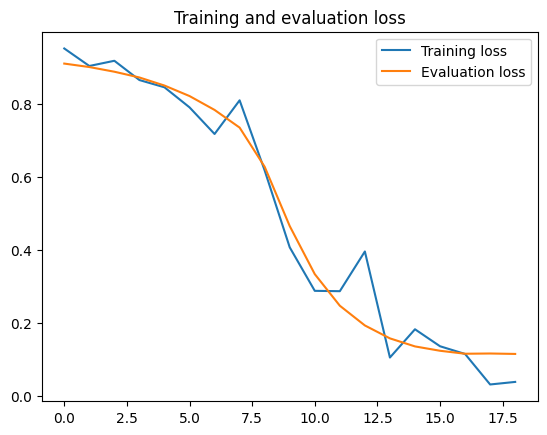

In [129]:
# Training and evaluation loss
train_loss = history['train_loss']
eval_loss = history['eval_loss']
plt.plot(train_loss, label='Training loss')
plt.plot(eval_loss, label='Evaluation loss')
plt.title('Training and evaluation loss')
plt.legend()

In [130]:
# Evaluate the model (optimize this result before evaluating performance on test set)
result, model_outputs, wrong_predictions = model.eval_model(dev)
result

/usr/local/lib/python3.11/dist-packages/simpletransformers/classification/classification_model.py:1453: UserWarning: Dataframe headers not specified. Falling back to using column 0 as text and column 1 as labels.
  warnings.warn(


  0%|          | 0/7 [00:00<?, ?it/s]

Running Evaluation:   0%|          | 0/36 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/simpletransformers/classification/classification_model.py:1505: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


{'mcc': np.float64(0.9443153788848104), 'eval_loss': 0.11525899192525281}

The Matthews Correlation Coefficient (MCC) takes into account true and false positives and negatives. It is a balanced measure even when classes are of varying size. An MCC of circa 0.944 suggests that the model is performing well; a score of 1 would indicate perfect correlation. There is a strong correlation between the labels predicted by the BERT model and actual labels.

For the evaluation loss, a lower score indicates better performance. It is the loss computed on the validation dataset, where a loss of 0 would indicate no difference between predicted and actual labels (no errors). A loss of 0.115 suggests that the predictions made by the BERT model are close to the true values.

## Make predictions for the test set and evaluate

Make predictions with the model (predict the labels of the documents in the test set)

In [122]:
# Make and store predictions
#predicted, probabilities = model.predict(test.text.to_list())
#test['predicted'] = predicted

Evaluate the model's performance on the test set

In [123]:
# Result
#print(classification_report(test['labels'], test['predicted']))